In [1]:
from scipy.io import loadmat
import cv2
import numpy as np

from math import sin, cos

import matplotlib.pyplot as plt
%matplotlib inline

In [49]:
data = loadmat("../../data/300W-LP/300W_LP/AFW/AFW_134212_1_0.mat")

In [50]:
data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'pt2d', 'roi', 'Illum_Para', 'Color_Para', 'Tex_Para', 'Shape_Para', 'Exp_Para', 'Pose_Para'])

In [51]:
data["roi"]

array([[ 532, -100, 1120,  488]], dtype=int16)

In [52]:
pitch, yaw, roll = data['Pose_Para'][0,:3]

In [53]:
yaw, pitch, roll

(0.46892217, -0.31765673, -0.15036292)

In [102]:
def draw_axis(img, yaw, pitch, roll, tdx=None, tdy=None, size = 100):

    # pitch = pitch * (np.pi/180)
    # yaw = yaw * np.pi / 180
    # roll = roll * np.pi / 180

#     pitch = pitch * 180/np.pi
#     yaw = -(yaw * 180/np.pi)
#     roll = roll * 180/np.pi
    
    print(pitch, yaw, roll)

    if tdx != None and tdy != None:
        tdx = tdx
        tdy = tdy
    else:
        height, width = img.shape[:2]
        tdx = width / 2
        tdy = height / 2

    # X-Axis pointing to right. drawn in red
    x1 = size * (cos(yaw) * cos(roll)) + tdx
    y1 = size * (cos(pitch) * sin(roll) + cos(roll) * sin(pitch) * sin(yaw)) + tdy

    # Y-Axis | drawn in green
    #        v
    x2 = size * (-cos(yaw) * sin(roll)) + tdx
    y2 = size * (cos(pitch) * cos(roll) - sin(pitch) * sin(yaw) * sin(roll)) + tdy

    # Z-Axis (out of the screen) drawn in blue
    x3 = size * (sin(yaw)) + tdx
    y3 = size * (-cos(yaw) * sin(pitch)) + tdy

    cv2.line(img, (int(tdx), int(tdy)), (int(x1),int(y1)),(0,0,255),3)
    cv2.line(img, (int(tdx), int(tdy)), (int(x2),int(y2)),(0,255,0),3)
    cv2.line(img, (int(tdx), int(tdy)), (int(x3),int(y3)),(255,0,0),2)

    return img

In [103]:
image = cv2.imread("../../data/300W-LP/300W_LP/AFW/AFW_134212_1_0.jpg")

In [104]:
axis_img = draw_axis(image, yaw, pitch, roll, tdx=200, tdy=200)

-0.31765673 0.46892217 -0.15036292


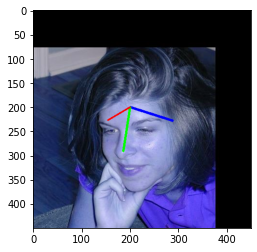

In [101]:
plt.imshow(axis_img)
plt.show()

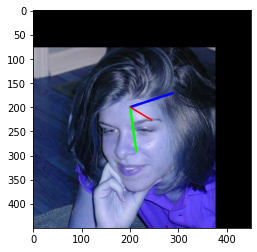

In [105]:
plt.imshow(axis_img)
plt.show()